# Nghiên cứu ứng dụng Trí tuệ Nhân tạo hỗ trợ Sàng lọc các Bệnh lý Đáy mắt và Phát hiện sớm Viêm võng mạc sắc tố (RP)

**Tác giả:** Nhóm nghiên cứu AI Y tế  
**Bộ dữ liệu:** Eye-Fundus-10 (Kaggle)  
**Mô hình:** EfficientNetB0 (Transfer Learning & Fine-tuning)  

---
### Tóm tắt quy trình thực hiện:
1. **Tiền xử lý & Khử rò rỉ dữ liệu:** Lọc bỏ lớp bệnh `Pterygium` (bệnh bề mặt nhãn cầu, không phải đáy mắt), sử dụng mã băm MD5 để kiểm tra và loại bỏ 345 ảnh trùng lặp giữa các tập Train - Valid - Test.
2. **Xử lý mất cân bằng:** Áp dụng Class Weights (trọng số lớp cân bằng) kết hợp Data Augmentation thời gian thực.
3. **Huấn luyện 2 giai đoạn:**
   - **Giai đoạn 1:** Transfer Learning với EfficientNetB0 (đóng băng backbone).
   - **Giai đoạn 2:** Fine-tuning 30 lớp cuối cùng với Learning Rate nhỏ (`1e-4`).
4. **Đánh giá & Trực quan hóa:** Đánh giá bằng Classification Report, Confusion Matrix và bản đồ nhiệt Grad-CAM.

## 1. Khai báo Thư viện và Cấu hình Môi trường

In [1]:
import os
import glob
import hashlib
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

# Thiết lập hạt giống ngẫu nhiên cho tính tái lập (Reproducibility)
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Cấu hình tham số huấn luyện
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_PHASE1 = 15
EPOCHS_PHASE2 = 15

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## 2. Tiền xử lý Dữ liệu và Kiểm soát Rò rỉ (Data Leakage)

### 2.1 Cấu hình thư mục và Lọc lớp dữ liệu (Loại bỏ Pterygium)

In [3]:
BASE_DIR = '/kaggle/input/datasets/ermano123/eye-fundus10/eye'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'valid')
TEST_DIR = os.path.join(BASE_DIR, 'test')

# Lọc danh sách lớp: Loại bỏ Pterygium (bệnh bề mặt nhãn cầu)
all_classes = sorted(os.listdir(TRAIN_DIR))
SELECTED_CLASSES = [cls for cls in all_classes if cls != 'Pterygium']
num_classes = len(SELECTED_CLASSES)

print(f"Số lượng lớp huấn luyện thực tế: {num_classes}")
print("Danh sách các lớp:", SELECTED_CLASSES)

Số lượng lớp huấn luyện thực tế: 9
Danh sách các lớp: ['Central Serous Chorioretinopathy ', 'Diabetic Retinopathy', 'Disc Edema', 'Glaucoma', 'Healthy', 'Macular Scar', 'Myopia', 'Retinal Detachment', 'Retinitis Pigmentosa']


### 2.2 Kiểm tra và Khử trùng lặp ảnh bằng mã băm MD5

In [4]:
def get_file_hash(file_path):
    """Tính toán mã băm MD5 để định danh duy nhất nội dung ảnh."""
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

def check_leakage(dir1, dir2, label1="Tập 1", label2="Tập 2"):
    """So sánh trùng lặp ảnh giữa 2 thư mục dựa trên mã MD5 hash."""
    hashes1 = {get_file_hash(os.path.join(root, f)) for root, _, files in os.walk(dir1) for f in files}
    hashes2 = {get_file_hash(os.path.join(root, f)) for root, _, files in os.walk(dir2) for f in files}
    duplicates = hashes1.intersection(hashes2)
    print(f"--- Kiểm tra rò rỉ: {label1} vs {label2} ---")
    print(f"Số mẫu duy nhất {label1}: {len(hashes1)} | {label2}: {len(hashes2)}")
    print(f"Số ảnh trùng lặp nội dung: {len(duplicates)}")
    return duplicates

# Kiểm tra rò rỉ giữa tập Train và các tập kiểm định / kiểm thử
leak_train_test = check_leakage(TRAIN_DIR, TEST_DIR, "TRAIN", "TEST")
leak_train_val = check_leakage(TRAIN_DIR, VAL_DIR, "TRAIN", "VALID")
leaked_hashes = leak_train_test.union(leak_train_val)

# Tạo DataFrame tập Train và lọc sạch ảnh bị rò rỉ
train_records = []
for root, _, files in os.walk(TRAIN_DIR):
    cls_name = os.path.basename(root)
    if cls_name in SELECTED_CLASSES:
        for f in files:
            train_records.append({'file_path': os.path.join(root, f), 'label': cls_name})

train_df = pd.DataFrame(train_records)
train_df_cleaned = train_df[~train_df['file_path'].apply(get_file_hash).isin(leaked_hashes)].reset_index(drop=True)

print(f"\nSố lượng ảnh Train ban đầu: {len(train_df)}")
print(f"Số lượng ảnh Train sau khi khử trùng: {len(train_df_cleaned)}")

--- Kiểm tra rò rỉ: TRAIN vs TEST ---
Số mẫu duy nhất TRAIN: 11047 | TEST: 1621
Số ảnh trùng lặp nội dung: 106
--- Kiểm tra rò rỉ: TRAIN vs VALID ---
Số mẫu duy nhất TRAIN: 11047 | VALID: 3219
Số ảnh trùng lặp nội dung: 229

Số lượng ảnh Train ban đầu: 11293
Số lượng ảnh Train sau khi khử trùng: 10948


### 2.3 Thống kê phân bố tập dữ liệu sạch

/tmp/ipykernel_58/3218575727.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Số lượng sạch', y='Bệnh lý', data=clean_counts, palette='viridis')


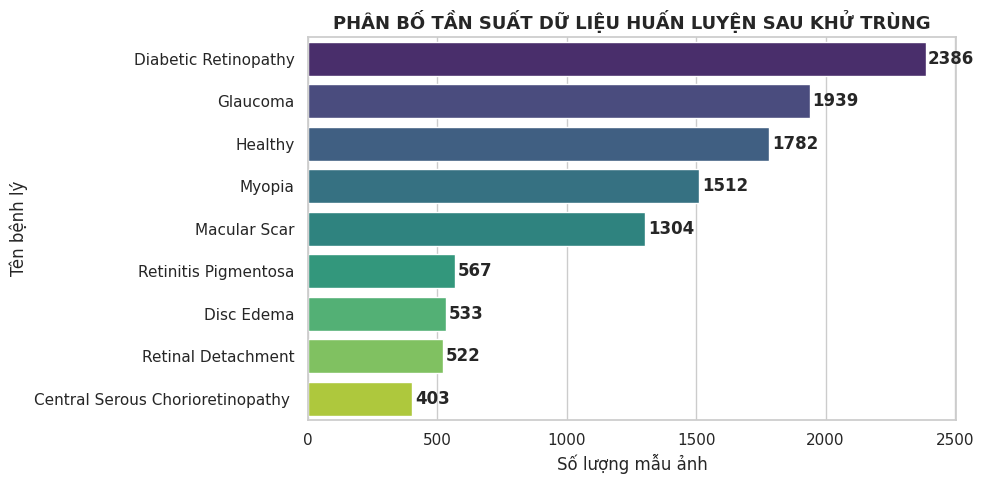

In [5]:
clean_counts = train_df_cleaned['label'].value_counts().reset_index()
clean_counts.columns = ['Bệnh lý', 'Số lượng sạch']

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x='Số lượng sạch', y='Bệnh lý', data=clean_counts, palette='viridis')

for i, row in clean_counts.iterrows():
    ax.text(row['Số lượng sạch'] + 10, i, f"{int(row['Số lượng sạch'])}", va='center', fontweight='bold')

plt.title('PHÂN BỐ TẦN SUẤT DỮ LIỆU HUẤN LUYỆN SAU KHỬ TRÙNG', fontsize=13, fontweight='bold')
plt.xlabel('Số lượng mẫu ảnh')
plt.ylabel('Tên bệnh lý')
plt.tight_layout()
plt.show()

### 2.4 Cấu hình Data Pipelines và Data Augmentation

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1)
], name="data_augmentation")


def load_dataset_from_df(df, subset_classes, shuffle=True):
    filepaths = df['file_path'].values
    label_to_index = {name: i for i, name in enumerate(subset_classes)}
    labels_int = np.array([label_to_index[lbl] for lbl in df['label'].values])
    labels_onehot = tf.keras.utils.to_categorical(labels_int, num_classes=len(subset_classes))

    def _parse_function(filename, label):
        image_string = tf.io.read_file(filename)
        image_decoded = tf.image.decode_jpeg(image_string, channels=3)
        image_resized = tf.image.resize(image_decoded, IMG_SIZE)
        return image_resized, label

    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels_onehot))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(filepaths), seed=SEED)
    dataset = dataset.map(_parse_function, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    return dataset

def load_dataset_from_dir(dir_path, subset_classes, shuffle=True):
    return keras.utils.image_dataset_from_directory(
        dir_path,
        labels='inferred',
        label_mode='categorical',
        class_names=subset_classes,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle
    )

train_ds = load_dataset_from_df(train_df_cleaned, SELECTED_CLASSES, shuffle=True)
val_ds = load_dataset_from_dir(VAL_DIR, SELECTED_CLASSES, shuffle=False)
test_ds = load_dataset_from_dir(TEST_DIR, SELECTED_CLASSES, shuffle=False)

AUTOTUNE = tf.data.AUTOTUNE

def preprocess_train(image, label):
    return data_augmentation(image), label

train_ds = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE).cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

I0000 00:00:1786121278.481419      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 3225 files belonging to 9 classes.
Found 1622 files belonging to 9 classes.


## 3. Tính toán Trọng số Lớp (Class Weights)

In [7]:
y_train_labels = train_df_cleaned['label'].values
label_to_index = {name: i for i, name in enumerate(SELECTED_CLASSES)}
y_train_int = np.array([label_to_index[lbl] for lbl in y_train_labels])

class_weights_vals = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weights = dict(enumerate(class_weights_vals))

print("Bảng Class Weights tính trên tập dữ liệu sạch:")
for i, name in enumerate(SELECTED_CLASSES):
    print(f"  Lớp {i} ({name}): {class_weights[i]:.4f}")

Bảng Class Weights tính trên tập dữ liệu sạch:
  Lớp 0 (Central Serous Chorioretinopathy ): 3.0185
  Lớp 1 (Diabetic Retinopathy): 0.5098
  Lớp 2 (Disc Edema): 2.2823
  Lớp 3 (Glaucoma): 0.6274
  Lớp 4 (Healthy): 0.6826
  Lớp 5 (Macular Scar): 0.9329
  Lớp 6 (Myopia): 0.8045
  Lớp 7 (Retinal Detachment): 2.3304
  Lớp 8 (Retinitis Pigmentosa): 2.1454


## 4. Xây dựng Kiến trúc Mô hình EfficientNetB0

In [8]:
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Đóng băng backbone cho Giai đoạn 1

inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs, name="EfficientNetB0_Retinal")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Recall(name='recall'), keras.metrics.Precision(name='precision')]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_Retinal"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385,964 (16.73 MB)

 Trainable params: 333,321 (1.27 MB)

 Non-trainable params: 4,052,643 (15.46 MB)

## 5. Huấn luyện Mô hình 2 Giai đoạn (Two-Stage Training)

### 5.1 Giai đoạn 1: Huấn luyện Top Layers (Frozen Backbone)

In [9]:
callbacks_phase1 = [
    ModelCheckpoint("best_efficientnet_phase1.keras", save_best_only=True, monitor="val_loss", mode='min'),
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)
]

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    class_weight=class_weights,
    callbacks=callbacks_phase1
)

Epoch 1/15


I0000 00:00:1786121310.412305     139 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


343/343 ━━━━━━━━━━━━━━━━━━━━ 112s 247ms/step - accuracy: 0.4785 - loss: 1.4621 - precision: 0.5646 - recall: 0.3792 - val_accuracy: 0.6447 - val_loss: 1.0015 - val_precision: 0.8301 - val_recall: 0.4211 - learning_rate: 0.0010
Epoch 2/15
343/343 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.5960 - loss: 1.0125 - precision: 0.6938 - recall: 0.4922 - val_accuracy: 0.6496 - val_loss: 0.9114 - val_precision: 0.7663 - val_recall: 0.5206 - learning_rate: 0.0010
Epoch 3/15
343/343 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.6200 - loss: 0.9094 - precision: 0.7199 - recall: 0.5162 - val_accuracy: 0.6791 - val_loss: 0.8432 - val_precision: 0.7868 - val_recall: 0.5631 - learning_rate: 0.0010
Epoch 4/15
343/343 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.6445 - loss: 0.8352 - precision: 0.7393 - recall: 0.5451 - val_accuracy: 0.6840 - val_loss: 0.8253 - val_precision: 0.7885 - val_recall: 0.5631 - learning_rate: 0.0010
Epoch 5/15
343/343 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy:

### 5.2 Giai đoạn 2: Fine-Tuning 30 Lớp Cuối cùng

In [10]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Recall(name='recall'), keras.metrics.Precision(name='precision')]
)

callbacks_phase2 = [
    ModelCheckpoint("best_efficientnet_finetuned.keras", save_best_only=True, monitor="val_loss", mode='min'),
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7)
]

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    class_weight=class_weights,
    callbacks=callbacks_phase2
)

Epoch 1/15


2026-08-07 16:53:16.581844: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 16:53:16.788966: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 16:53:17.213819: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 16:53:17.421350: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


341/343 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6073 - loss: 1.0193 - precision: 0.6767 - recall: 0.5303

2026-08-07 16:53:44.323627: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-07 16:53:44.528742: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


343/343 ━━━━━━━━━━━━━━━━━━━━ 70s 117ms/step - accuracy: 0.6408 - loss: 0.8901 - precision: 0.7095 - recall: 0.5710 - val_accuracy: 0.7005 - val_loss: 0.8027 - val_precision: 0.7692 - val_recall: 0.6282 - learning_rate: 1.0000e-04
Epoch 2/15
343/343 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.7076 - loss: 0.6479 - precision: 0.7674 - recall: 0.6431 - val_accuracy: 0.7333 - val_loss: 0.7182 - val_precision: 0.7885 - val_recall: 0.6784 - learning_rate: 1.0000e-04
Epoch 3/15
343/343 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.7480 - loss: 0.5382 - precision: 0.8034 - recall: 0.6885 - val_accuracy: 0.7371 - val_loss: 0.7100 - val_precision: 0.7857 - val_recall: 0.6843 - learning_rate: 1.0000e-04
Epoch 4/15
343/343 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.7773 - loss: 0.4823 - precision: 0.8266 - recall: 0.7243 - val_accuracy: 0.7678 - val_loss: 0.6342 - val_precision: 0.8091 - val_recall: 0.7150 - learning_rate: 1.0000e-04
Epoch 5/15
343/343 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/s

### 5.3 Trực quan hóa Lịch sử Huấn luyện

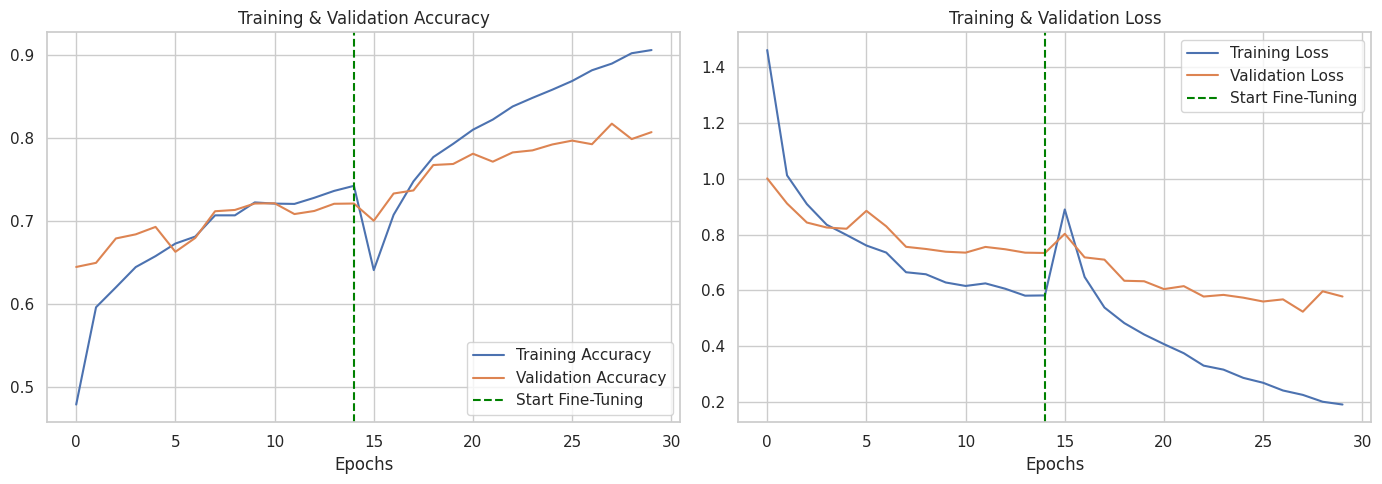

In [11]:
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

initial_epochs = len(history_phase1.history['loss'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(acc, label='Training Accuracy')
ax1.plot(val_acc, label='Validation Accuracy')
ax1.axvline(x=initial_epochs-1, color='green', linestyle='--', label='Start Fine-Tuning')
ax1.set_title('Training & Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.legend(loc='lower right')

ax2.plot(loss, label='Training Loss')
ax2.plot(val_loss, label='Validation Loss')
ax2.axvline(x=initial_epochs-1, color='green', linestyle='--', label='Start Fine-Tuning')
ax2.set_title('Training & Validation Loss')
ax2.set_xlabel('Epochs')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 6. Đánh giá Mô hình trên Tập Kiểm tra (Test Set)

Đã tải mô hình checkpoint tốt nhất từ Phase 2.
Đang đánh giá đồng bộ trên tập Test...

--- CLASSIFICATION REPORT (TEST SET) ---
                                   precision    recall  f1-score   support

Central Serous Chorioretinopathy        0.82      0.69      0.75        61
             Diabetic Retinopathy       0.95      0.88      0.91       346
                       Disc Edema       0.91      0.97      0.94        77
                         Glaucoma       0.71      0.55      0.62       289
                          Healthy       0.63      0.85      0.72       268
                     Macular Scar       0.67      0.75      0.71       195
                           Myopia       0.79      0.68      0.73       226
               Retinal Detachment       0.97      0.97      0.97        75
             Retinitis Pigmentosa       0.85      0.96      0.90        85

                         accuracy                           0.78      1622
                        macro avg       0.81 

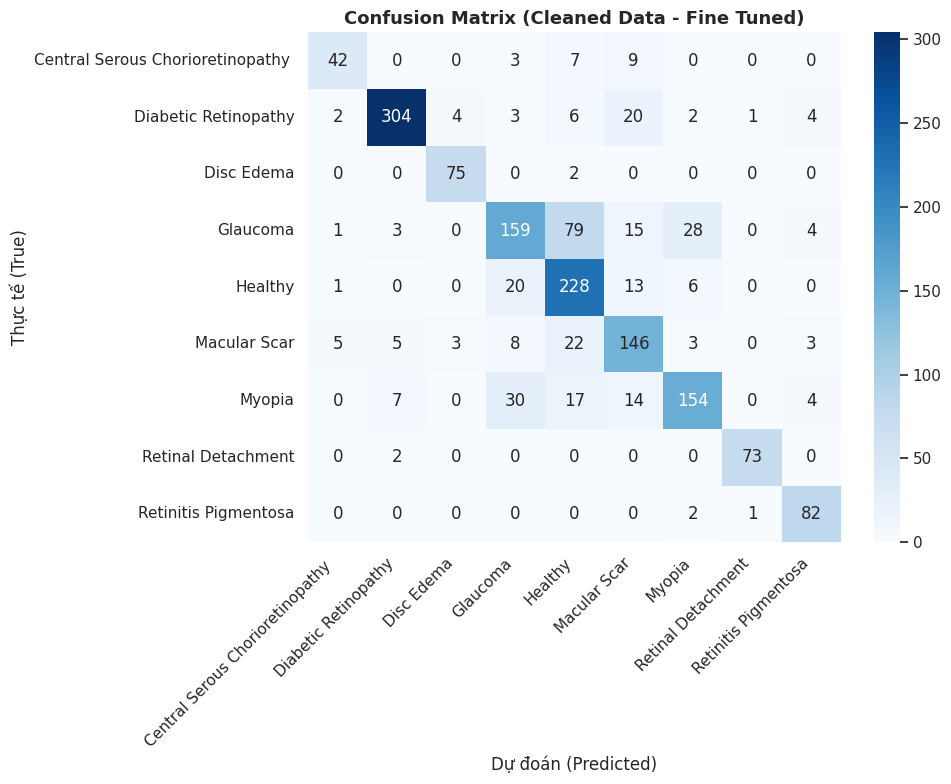

In [12]:
try:
    best_model = keras.models.load_model("best_efficientnet_finetuned.keras")
    print("Đã tải mô hình checkpoint tốt nhất từ Phase 2.")
except Exception:
    best_model = model

print("Đang đánh giá đồng bộ trên tập Test...")
y_true_list = []
y_pred_list = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_pred_list.append(preds)
    y_true_list.append(labels.numpy())

y_pred_probs = np.vstack(y_pred_list)
y_true_onehot = np.vstack(y_true_list)

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_true_onehot, axis=1)

print("\n--- CLASSIFICATION REPORT (TEST SET) ---")
print(classification_report(y_true, y_pred, target_names=SELECTED_CLASSES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=SELECTED_CLASSES, yticklabels=SELECTED_CLASSES)
plt.title('Confusion Matrix (Cleaned Data - Fine Tuned)', fontsize=13, fontweight='bold')
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (True)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Giải thích Mô hình bằng Grad-CAM (Gradient-weighted Class Activation Mapping)

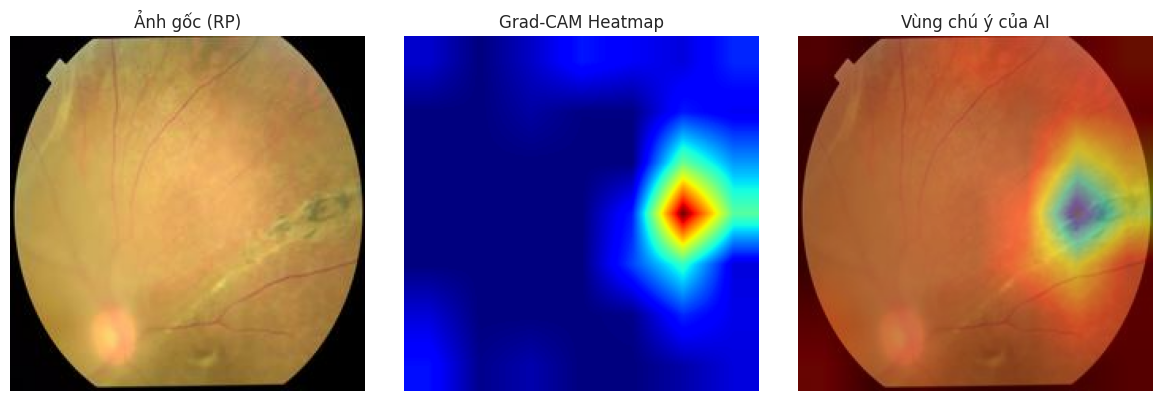

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="top_activation", pred_index=None):
    try:
        base_model = model.get_layer('efficientnetb0')
        conv_layer = base_model.get_layer(last_conv_layer_name)
    except Exception:
        conv_layer = model.get_layer(last_conv_layer_name)

    conv_model = keras.Model(inputs=base_model.inputs, outputs=conv_layer.output)

    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_array)
        tape.watch(conv_outputs)

        x = model.get_layer('global_average_pooling2d')(conv_outputs)
        for layer in model.layers:
            if layer.name not in [model.layers[0].name, 'efficientnetb0', 'global_average_pooling2d']:
                x = layer(x)
        preds = x  

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

   
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()


rp_class_idx = SELECTED_CLASSES.index('Retinitis Pigmentosa')
found_rp = False

for images, labels in test_ds:
    if found_rp:
        break
    for i in range(len(labels)):
        if np.argmax(labels[i]) == rp_class_idx:
            img_tensor = tf.expand_dims(images[i], axis=0)
            
            heatmap = make_gradcam_heatmap(img_tensor, best_model, last_conv_layer_name="top_activation", pred_index=rp_class_idx)
            
            orig_img = images[i].numpy().astype('uint8')
            resized_heatmap = cv2.resize(heatmap, (224, 224))
            resized_heatmap = np.uint8(255 * resized_heatmap)
            color_heatmap = cv2.applyColorMap(resized_heatmap, cv2.COLORMAP_JET)
            superimposed_img = cv2.addWeighted(orig_img, 0.6, color_heatmap, 0.4, 0)
            
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(orig_img)
            axes[0].set_title("Ảnh gốc (RP)")
            axes[0].axis('off')

            axes[1].imshow(resized_heatmap, cmap='jet')
            axes[1].set_title("Grad-CAM Heatmap")
            axes[1].axis('off')

            axes[2].imshow(superimposed_img)
            axes[2].set_title("Vùng chú ý của AI")
            axes[2].axis('off')

            plt.tight_layout()
            plt.show()
            
            found_rp = True
            break
